In [54]:
#sistemare la rete neurale lstm

In [38]:
import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import itertools
import seaborn as sns
from datetime import datetime
import re
import string
import chardet
import html
from collections import Counter
import plotly.express as px
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.probability import FreqDist
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_distances
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
import scipy.sparse as sp
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Activation, Reshape, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy
from tensorflow.keras.regularizers import l2
from imblearn.over_sampling import SMOTE
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
# Caricamento dati
reviews_a = pd.read_csv("Scraped_Car_Review_tesla.csv", encoding="MacRoman", quoting=1)

In [3]:
reviews_a.head

<bound method NDFrame.head of      Unnamed: 0                  Review_Date      Author_Name  \
0             0   on 08/30/18 15:36 PM (PDT)              TN    
1             1   on 07/04/18 17:15 PM (PDT)          Ryan W    
2             2   on 06/21/18 05:22 AM (PDT)          Bamboo    
3             3   on 04/07/18 15:01 PM (PDT)             Mel    
4             4   on 12/30/17 21:45 PM (PST)  Dallen Ormond     
..          ...                          ...              ...   
135         135   on 06/30/13 17:27 PM (PDT)    amazinggrace    
136         136   on 06/13/13 20:30 PM (PDT)     smccphillip    
137         137   on 05/20/13 17:43 PM (PDT)      drbones911    
138         138   on 04/14/13 15:47 PM (PDT)       dwoodruff    
139         139   on 03/09/13 15:39 PM (PST)     txcattledog    

                                         Vehicle_Title  \
0    2018 Tesla Model X SUV 75D 4dr SUV AWD (electr...   
1    2018 Tesla Model X SUV 100D 4dr SUV AWD (elect...   
2    2017 Tesla

In [4]:
reviews_a.shape

(140, 7)

In [5]:
print (reviews_a.columns)

Index(['Unnamed: 0', 'Review_Date', 'Author_Name', 'Vehicle_Title',
       'Review_Title', 'Review', 'Rating'],
      dtype='object')


In [6]:
reviews_a.dtypes

Unnamed: 0         int64
Review_Date       object
Author_Name       object
Vehicle_Title     object
Review_Title      object
Review            object
Rating           float64
dtype: object

In [7]:
# Funzione per estrarre la data e convertirla in formato datetime
def extract_date(timestamp):
    date_str = timestamp.split()[1]
    return datetime.strptime(date_str, '%m/%d/%y')

# Applicazione della funzione
reviews_a['Time'] = reviews_a['Review_Date'].apply(extract_date)

In [8]:
reviews_a.dtypes

Unnamed: 0                int64
Review_Date              object
Author_Name              object
Vehicle_Title            object
Review_Title             object
Review                   object
Rating                  float64
Time             datetime64[ns]
dtype: object

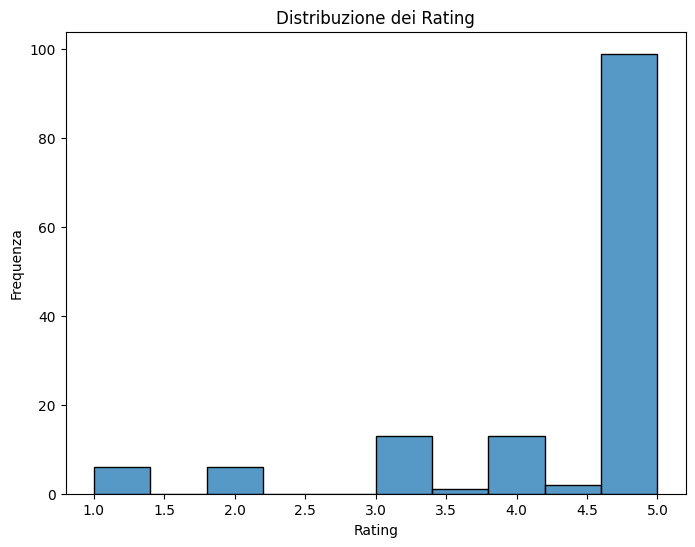

In [9]:
# Istogramma per la colonna 'Rating'
plt.figure(figsize=(8, 6))
sns.histplot(reviews_a['Rating'], bins=10)
plt.title('Distribuzione dei Rating')
plt.xlabel('Rating')
plt.ylabel('Frequenza')
plt.show()

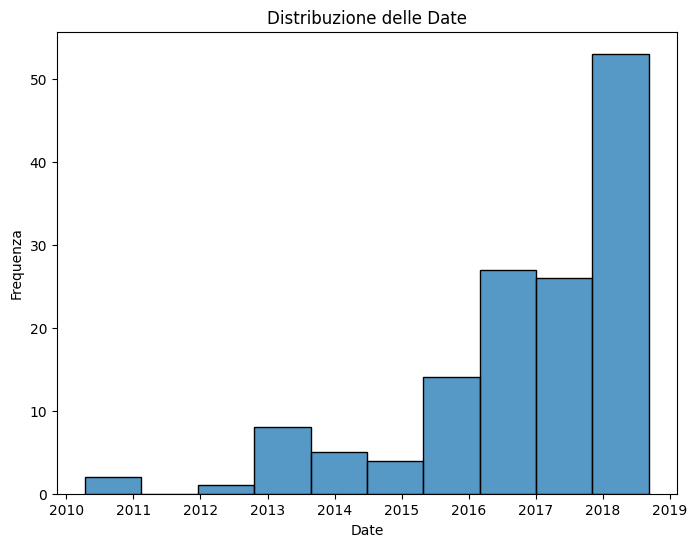

In [10]:
plt.figure(figsize=(8, 6))
sns.histplot(reviews_a['Time'], bins=10)  # kde=True aggiunge la stima della densità di kernel
plt.title('Distribuzione delle Date')
plt.xlabel('Date')
plt.ylabel('Frequenza')
plt.show()

In [11]:
# Dizionario di slang e acronimi (aggiungere altri se necessario)
slang_dict = {
    "u": "you", "ur": "your", "r": "are", "idk": "I don't know", "btw": "by the way",
    "imo": "in my opinion", "imho": "in my humble opinion", "lol": "laughing out loud",
    "lmao": "laughing my ass off", "brb": "be right back", "gtg": "got to go",
    "smh": "shaking my head", "omg": "oh my god", "thx": "thanks", "ty": "thank you",
    "pls": "please", "plz": "please", "gr8": "great", "b4": "before", "cuz": "because",
    "bc": "because", "wanna": "want to", "gonna": "going to", "gotta": "got to"
}
def clean_text(text):
    # Convertire in minuscolo
    text = text.lower()
    # Decodifica entità HTML (&quot; -> ", &amp; -> &, ecc.)
    text = html.unescape(text)
    # Rimuovere menzioni, URL e hashtag
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)  # Menzioni
    text = re.sub(r'https?://\S+', '', text)   # URL
    text = re.sub(r'#', '', text)               # Rimuove hashtag mantenendo la parola
    text = re.sub(r'www\.\S+', '', text)    # Rimuove URL che iniziano con www
    
    # Sostituzione di acronimi e slang
    words = text.split()
    words = [slang_dict[word] if word in slang_dict else word for word in words]
    text = ' '.join(words)
    
    # Rimozione di punteggiatura e numeri
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    # Tokenizzazione
    tokens = word_tokenize(text)
    
    # Rimozione stopwords
    stop_words = set(stopwords.words('english'))
    
    tokens = [word for word in tokens if word not in stop_words]

    # Rimozione della parola "walmart"
    words_to_remove = ["tesla", "car"]
    tokens = [word for word in tokens if word not in words_to_remove]
    
    # Stemming
    stemmer = PorterStemmer()
    tokens = [stemmer.stem(word) for word in tokens]
    
    return ' '.join(tokens)

In [12]:
# Applicare la pulizia alla colonna "SentimentText"
reviews_a["Review"] = reviews_a["Review"].astype(str).apply(clean_text)
reviews_a["Review"].head

<bound method NDFrame.head of 0      model x uniqu either like hate like buy first ...
1      lot exist review onlin includ edmund review li...
2      like consum own five differ car want tri somet...
3      own three month tow servic center alreadi prob...
4      past year own differ vehicl purchas model x mo...
                             ...                        
135    husband accident spill cooler insid hit break ...
136    initi qualiti review mile sinc pick last week ...
137    approxim mile signatur perform version grab lo...
138    own model perform p week brilliant ever own ow...
139    year car improv increment chang last year impr...
Name: Review, Length: 140, dtype: object>

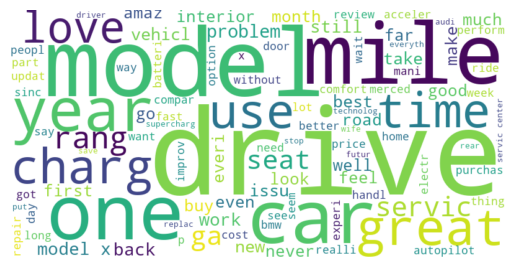

In [13]:
#nuvola di parole
text = " ".join(reviews_a['Review'])
wordcloud = WordCloud(width=800, height=400, max_words=100, background_color='white', colormap='viridis').generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

Parole più comuni nei testi positivi:
    Words  Counts
0  servic      20
1     get      15
2    door      15
3   drive      14
4   would      12
Parole più comuni nei testi neutrali:
    Words  Counts
0  servic      23
1   model      14
2    issu      13
3     get      10
4     car      10

Parole più comuni nei testi negativi:
   Words  Counts
0  drive     130
1  model      98
2   mile      73
3    get      70
4   like      64


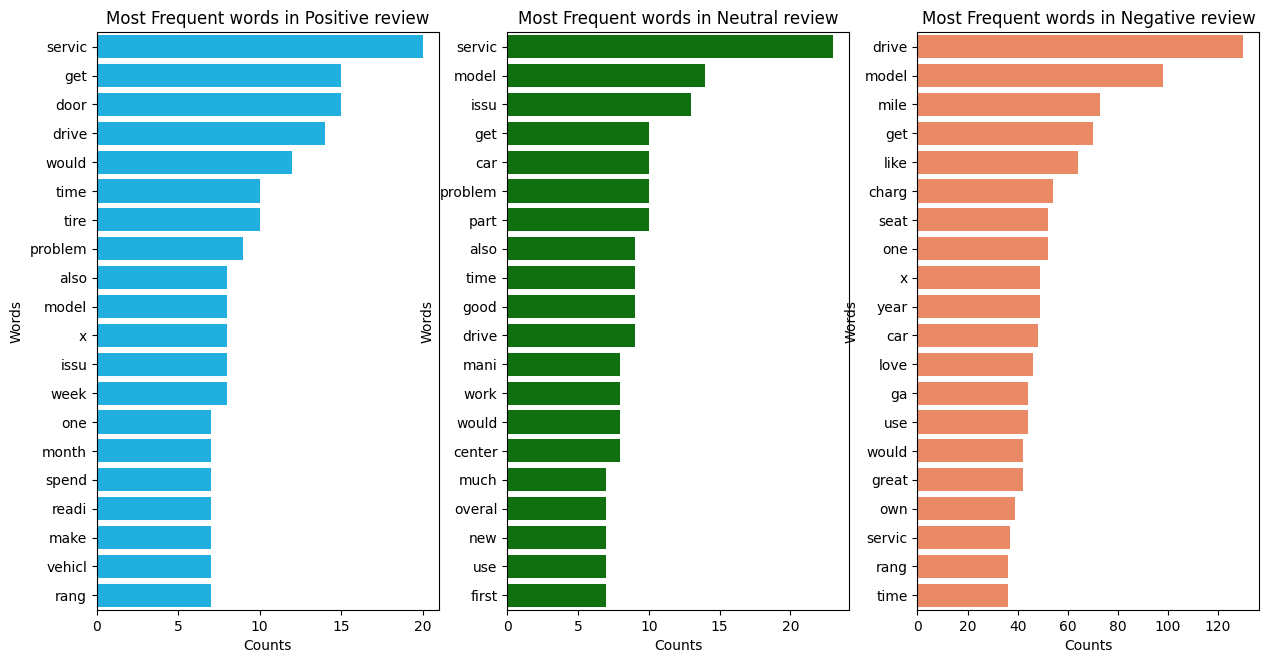

In [14]:
# Filtra i revies
positive_texts = " ".join(reviews_a[reviews_a['Rating'] == 1]['Review'])+' '.join(reviews_a[reviews_a['Rating'] == 2]['Review'])
neutral_texts= " ".join(reviews_a[reviews_a['Rating'] == 3]['Review'])
negative_texts = " ".join(reviews_a[reviews_a['Rating'] == 4]['Review'])+' '.join(reviews_a[reviews_a['Rating'] == 5]['Review'])


# Conta le parole più comuni per i testi positivi
top_pos = Counter(positive_texts.split())
top_pos_df = pd.DataFrame(top_pos.most_common(100), columns=['Words', 'Counts'])

# Conta le parole più comuni per i testi positivi
top_neu = Counter(neutral_texts.split())
top_neu_df = pd.DataFrame(top_neu.most_common(100), columns=['Words', 'Counts'])


# Conta le parole più comuni per i testi negativi
top_neg = Counter(negative_texts.split())
top_neg_df = pd.DataFrame(top_neg.most_common(100), columns=['Words', 'Counts'])

# Stampa i risultati
print("Parole più comuni nei testi positivi:")
print(top_pos_df.head())

print("Parole più comuni nei testi neutrali:")
print(top_neu_df.head())

print("\nParole più comuni nei testi negativi:")
print(top_neg_df.head())

fig,ax=plt.subplots(nrows=1,ncols=3,figsize=(15,7.5))
sns.barplot(y='Words',x='Counts',data=top_pos_df[:20],color='deepskyblue',ax=ax[0])
sns.barplot(y='Words',x='Counts',data=top_neu_df[:20],color='green',ax=ax[1])
sns.barplot(y='Words',x='Counts',data=top_neg_df[:20],color='coral',ax=ax[2])
ax[0].set_title("Most Frequent words in Positive review")
ax[1].set_title("Most Frequent words in Neutral review")
ax[2].set_title("Most Frequent words in Negative review")
plt.show()



In [15]:
#criteri empirici
def analisi_ttr_hapax(testo):
    tokens = word_tokenize(testo)
    tipi = set(tokens)
    ttr = len(tipi) / len(tokens) *100

    freq_dist = FreqDist(tokens)
    hapax = [word for word, freq in freq_dist.items() if freq == 1]
    percentuale_hapax = (len(hapax) / len(tokens)) * 100 if tokens else 0

    return ttr, percentuale_hapax

In [16]:
# Concatena tutte le recensioni in un'unica stringa
corpus_a = " ".join(reviews_a["Review"].tolist())

# Applica la funzione analisi_ttr_hapax all'intero corpus
ttr, percentuale_hapax = analisi_ttr_hapax(corpus_a)

# Stampa i risultati
print("TTR:", ttr)
print("Percentuale di Hapax:", percentuale_hapax)

TTR: 21.228478362028852
Percentuale di Hapax: 9.911586784550954


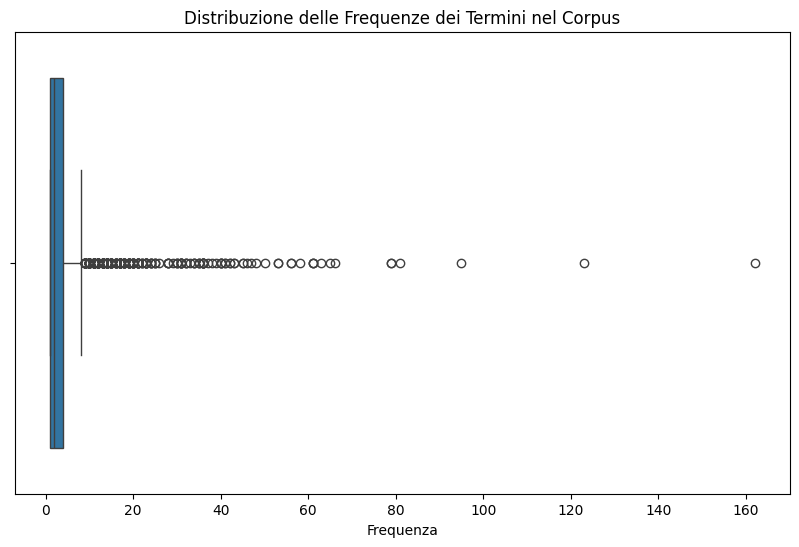

In [17]:
#TF
# Crea un oggetto CountVectorizer
vectorizer = CountVectorizer()

# Adatta il vectorizer al corpus e trasforma il corpus in una matrice TFM
tf_matrix_a = vectorizer.fit_transform([corpus_a]) 

# Ottieni i nomi delle feature (i termini)
feature_names = vectorizer.get_feature_names_out()

# Crea un DataFrame pandas dalla matrice TFM
tf_df_a = pd.DataFrame(tf_matrix_a.toarray(), columns=feature_names)

# Visualizzazione delle Frequenze dei Termini

# Calcola la somma delle frequenze per ogni termine
term_frequencies_a = tf_df_a.sum()

# a. Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=term_frequencies_a)
plt.title("Distribuzione delle Frequenze dei Termini nel Corpus")
plt.xlabel("Frequenza")
plt.show()

In [18]:
#applicare doc2vec con successiva riduzione della dimensione delle feature con modelli non lineari Tsne UMAP
#Vedere outlier con metodi densi

In [19]:
#Doc2Vec
tagged_data = []
for index, row in reviews_a.iterrows():
    tokens = word_tokenize(row['Review'].lower()) # Tokenizzazione e conversione in minuscolo
    tagged_data.append(TaggedDocument(words=tokens, tags=[str(index)])) # Usa l'indice come etichetta
model_dv = Doc2Vec(tagged_data, vector_size=100, window=5, epochs=50)

# Parametri importanti:
# - vector_size: la dimensionalità del vettore del documento
# - window: la dimensione della finestra di contesto
# - epochs: il numero di passaggi sull'intero corpus di addestramento
model_dv.build_vocab(tagged_data)
model_dv.train(tagged_data, total_examples=model_dv.corpus_count, epochs=model_dv.epochs)
X_doc2vec = [model_dv.infer_vector(doc.words) for doc in tagged_data]
X_doc2vec = pd.DataFrame(X_doc2vec) # Converti in DataFrame per SMOTE

--- Bilanciamento per il Rating ---
Distribuzione Rating prima di SMOTE: Counter({5: 94, 4: 20, 3: 14, 1: 6, 2: 6})
Distribuzione Rating dopo SMOTE: Counter({5: 94, 4: 94, 1: 94, 3: 94, 2: 94})


C:\Users\danie\AppData\Local\Temp\ipykernel_14532\3866004753.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_res_rating, palette='viridis', order=sorted(y_res_rating.unique()))


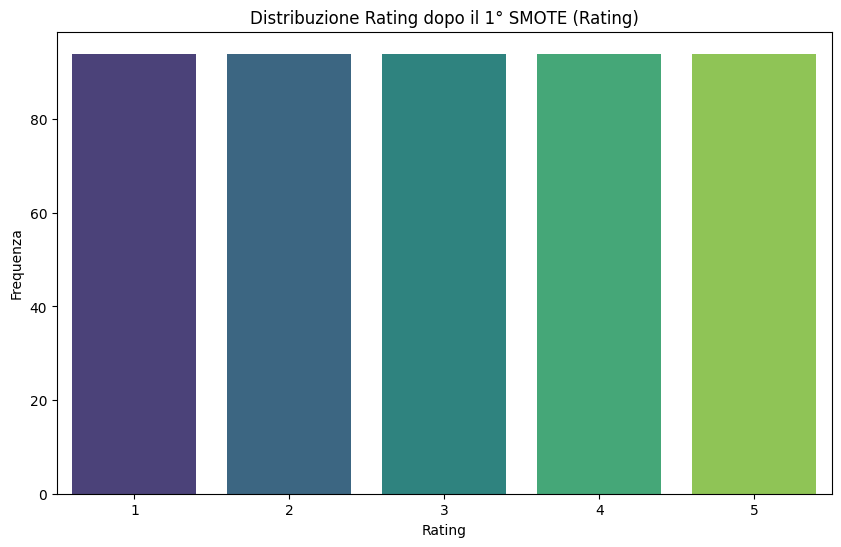


--- Bilanciamento per Anno-Quadrimestre (con date randomiche per i campioni sintetici di rating) ---
Distribuzione Anno-Quadrimestre prima del 2° SMOTE (con date randomiche per i sintetici): Counter({'2018-Q3': 36, '2018-Q2': 31, '2016-Q4': 26, '2013-Q2': 26, '2016-Q3': 25, '2014-Q1': 23, '2017-Q2': 22, '2017-Q1': 21, '2015-Q3': 20, '2018-Q1': 19, '2013-Q4': 18, '2015-Q4': 16, '2012-Q4': 16, '2014-Q4': 15, '2017-Q4': 14, '2015-Q2': 14, '2013-Q3': 14, '2012-Q3': 14, '2017-Q3': 13, '2016-Q2': 13, '2014-Q2': 13, '2013-Q1': 12, '2016-Q1': 10, '2012-Q2': 10, '2012-Q1': 9, '2015-Q1': 9, '2014-Q3': 9, '2010-Q2': 2})

Nessuna classe di Anno-Quadrimestre con esattamente 1 campione/i.

Distribuzione Anno-Quadrimestre dopo il 2° SMOTE: Counter({'2018-Q3': 36, '2018-Q2': 36, '2017-Q4': 36, '2017-Q3': 36, '2017-Q2': 36, '2017-Q1': 36, '2016-Q4': 36, '2016-Q3': 36, '2016-Q2': 36, '2010-Q2': 36, '2018-Q1': 36, '2016-Q1': 36, '2015-Q4': 36, '2015-Q3': 36, '2012-Q1': 36, '2015-Q1': 36, '2015-Q2': 36, 

C:\Users\danie\AppData\Local\Temp\ipykernel_14532\3866004753.py:155: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_res_final, palette='cividis', order=sorted(y_res_final.unique()))


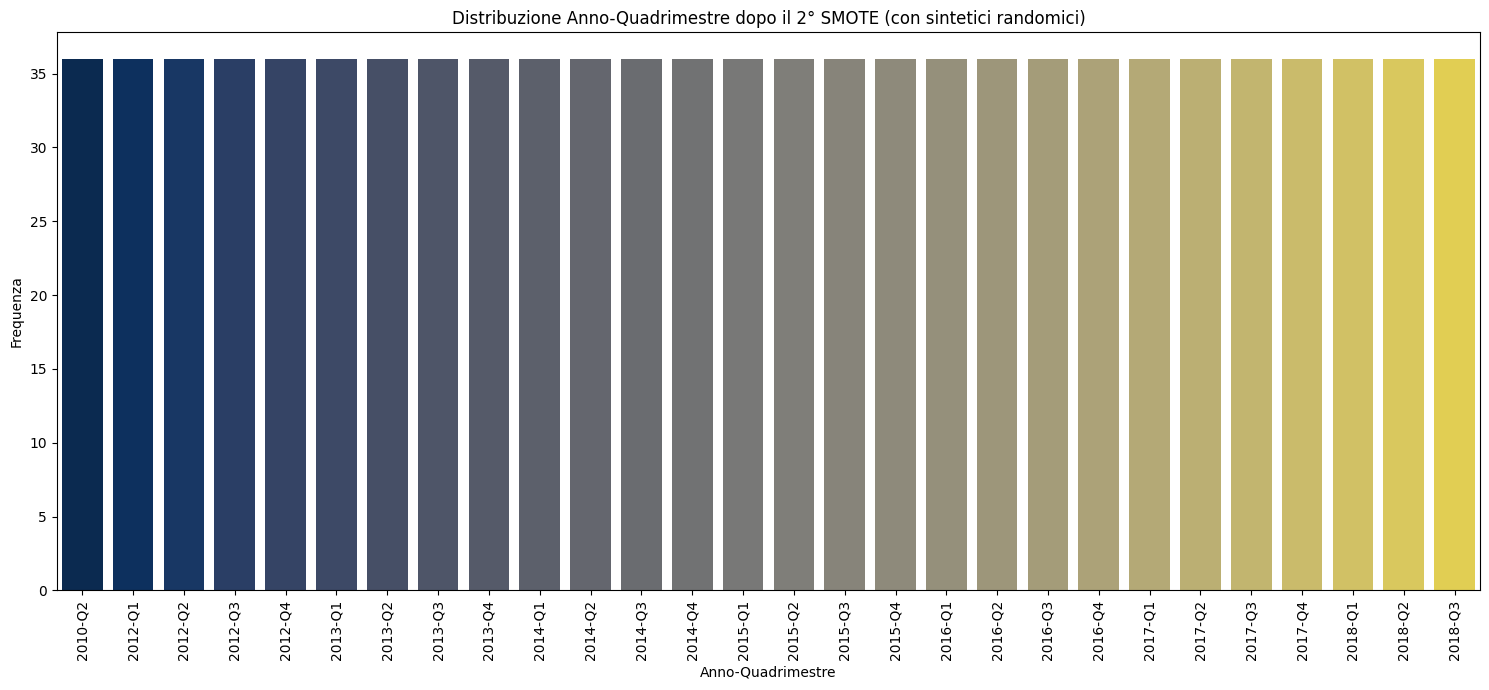


--- Riepilogo del Dataset Bilanciato Finale ---
Dopo l'applicazione sequenziale di SMOTE (Rating, poi Anno-Quadrimestre con date randomiche per i sintetici):
   - Feature: X_res_final (DataFrame con 1008 campioni e 100 feature)
   - Target: y_res_final (Series con 1008 campioni)
   Questo dataset è bilanciato sia per il rating che per l'anno-quadrimestre, con le date dei campioni sintetici di rating generate casualmente.

NOTA: Le classi di Anno-Quadrimestre con meno di 1 campioni non sono state sovra-campionate.


In [20]:
# --- Fase 1: Bilanciamento per il Rating ---

print("--- Bilanciamento per il Rating ---")
# Assicurati che y_rating sia di tipo intero discreto
y_rating = reviews_a['Rating'].astype(int)
X_initial = X_doc2vec # I vettori Doc2vec sono le nostre feature iniziali

print("Distribuzione Rating prima di SMOTE:", Counter(y_rating))

smote_rating = SMOTE(random_state=42)
X_res_rating, y_res_rating = smote_rating.fit_resample(X_initial, y_rating)

print("Distribuzione Rating dopo SMOTE:", Counter(y_res_rating))

# Visualizza la distribuzione del Rating dopo SMOTE
plt.figure(figsize=(10, 6))
sns.countplot(x=y_res_rating, palette='viridis', order=sorted(y_res_rating.unique()))
plt.title('Distribuzione Rating dopo il 1° SMOTE (Rating)')
plt.xlabel('Rating')
plt.ylabel('Frequenza')
plt.show()

# --- Fase 2: Bilanciamento per Anno-Quadrimestre (sul dataset già bilanciato per il rating, con date randomiche per i sintetici) ---

print("\n--- Bilanciamento per Anno-Quadrimestre (con date randomiche per i campioni sintetici di rating) ---")

# 1. Prepara la variabile 'anno_quadrimestre' per il dataset bilanciato per il rating
#    Per i campioni originali in X_res_rating, usiamo il loro 'anno_quadrimestre' originale.
#    Per i campioni sintetici (aggiunti da smote_rating), generiamo un 'anno_quadrimestre' randomico.

# Crea la colonna 'anno_quadrimestre' nel DataFrame originale
reviews_a['quadrimestre'] = reviews_a['Time'].dt.quarter
reviews_a['anno_quadrimestre'] = reviews_a['Time'].dt.year.astype(str) + '-Q' + reviews_a['quadrimestre'].astype(str)


# Determina quali campioni in X_res_rating sono originali e quali sono sintetici
n_original_samples = len(reviews_a)
is_original_sample = np.zeros(len(X_res_rating), dtype=bool)
is_original_sample[:n_original_samples] = True

# Crea la colonna 'anno_quadrimestre' per il dataset bilanciato del rating
anno_quadrimestre_for_smote_2 = pd.Series(index=X_res_rating.index, dtype=str)

# Assegna 'anno_quadrimestre' per i campioni originali
anno_quadrimestre_for_smote_2[is_original_sample] = reviews_a['anno_quadrimestre'].values

# Genera 'anno_quadrimestre' randomico per i campioni sintetici
synthetic_indices = X_res_rating.index[~is_original_sample]
num_synthetic_samples = len(synthetic_indices)

if num_synthetic_samples > 0:
    # IMPOSTA LA DATA MINIMA PER LA GENERAZIONE CASUALE AL 1 GENNAIO 2012
    min_date_for_synthetic = pd.to_datetime('2012-01-01')
    # Assicurati che la data massima per i sintetici non superi la data massima originale
    max_date_for_synthetic = reviews_a['Time'].max()

    # Calcola il range di giorni tra la data minima specificata e la data massima
    date_range_days = (max_date_for_synthetic - min_date_for_synthetic).days

    # Genera giorni casuali all'interno del nuovo range
    random_days = np.random.randint(0, date_range_days + 1, size=num_synthetic_samples)
    random_dates = min_date_for_synthetic + pd.to_timedelta(random_days, unit='D')
    
    # Converti le date casuali in formato anno-quadrimestre
    random_quadrimester = random_dates.quarter
    random_year = random_dates.year
    random_anno_quadrimestre = random_year.astype(str) + '-Q' + random_quadrimester.astype(str)

    anno_quadrimestre_for_smote_2[synthetic_indices] = random_anno_quadrimestre.values

# Ora, le feature per il secondo SMOTE sono X_res_rating
# e la target è la nuova Series 'anno_quadrimestre_for_smote_2'
X_for_anno_quadrimestre_smote = X_res_rating
y_for_anno_quadrimestre_smote = anno_quadrimestre_for_smote_2

print("Distribuzione Anno-Quadrimestre prima del 2° SMOTE (con date randomiche per i sintetici):", Counter(y_for_anno_quadrimestre_smote))

# Inizializza X_res_final e y_res_final a None prima del blocco try
X_res_final = None
y_res_final = None

# Imposta k_neighbors per SMOTE
smote_anno_quadrimestre_k = 1 # Imposta k_neighbors a 1 per consentire il sovra-campionamento di classi con un solo campione

# Identifica le classi di anno_quadrimestre che hanno meno di k_neighbors campioni
anno_quadrimestre_counts_before_smote = Counter(y_for_anno_quadrimestre_smote)
classes_with_too_few_samples = {
    cls: count for cls, count in anno_quadrimestre_counts_before_smote.items()
    if count < smote_anno_quadrimestre_k
}

# Identifica le classi con esattamente k_neighbors campioni
classes_with_k_neighbors_samples = {
    cls: count for cls, count in anno_quadrimestre_counts_before_smote.items()
    if count == smote_anno_quadrimestre_k
}

if classes_with_k_neighbors_samples:
    print(f"\nClassi di Anno-Quadrimestre con esattamente {smote_anno_quadrimestre_k} campione/i (k_neighbors):", classes_with_k_neighbors_samples)
else:
    print(f"\nNessuna classe di Anno-Quadrimestre con esattamente {smote_anno_quadrimestre_k} campione/i.")


# Se ci sono classi con meno di k_neighbors campioni, SMOTE non può gestirle.
# Filtriamo il dataset per includere solo le classi che possono essere sovra-campionate.
if classes_with_too_few_samples:
    print(f"\nATTENZIONE: Le seguenti classi di Anno-Quadrimestre hanno meno di {smote_anno_quadrimestre_k} campione/i e NON verranno sovra-campionate da SMOTE:")
    print(classes_with_too_few_samples)
    
    # Filtra X e Y per includere solo le classi che possono essere sovra-campionate
    classes_to_include_for_smote = {
        cls for cls, count in anno_quadrimestre_counts_before_smote.items()
        if count >= smote_anno_quadrimestre_k
    }
    indices_to_include = y_for_anno_quadrimestre_smote[y_for_anno_quadrimestre_smote.isin(classes_to_include_for_smote)].index
    X_filtered = X_for_anno_quadrimestre_smote.loc[indices_to_include]
    y_filtered = y_for_anno_quadrimestre_smote.loc[indices_to_include]

    if not classes_to_include_for_smote: # Se dopo il filtraggio non rimane nulla da campionare
        print("\nERRORE: Dopo il filtraggio, non ci sono classi di Anno-Quadrimestre con abbastanza campioni per essere sovra-campionate.")
        print("Il dataset finale sarà quello filtrato ma non bilanciato da SMOTE.")
        X_res_final = X_filtered
        y_res_final = y_filtered
    else:
        smote_anno_quadrimestre = SMOTE(random_state=42, k_neighbors=smote_anno_quadrimestre_k)
        try:
            # Applica SMOTE solo sulle classi che possono essere gestite
            X_res_final, y_res_final = smote_anno_quadrimestre.fit_resample(X_filtered, y_filtered)
            print("\nDistribuzione Anno-Quadrimestre dopo il 2° SMOTE (dopo il filtraggio):", Counter(y_res_final))

            # Visualizza la distribuzione Anno-Quadrimestre dopo SMOTE
            plt.figure(figsize=(15, 7))
            sns.countplot(x=y_res_final, palette='cividis', order=sorted(y_res_final.unique()))
            plt.title('Distribuzione Anno-Quadrimestre dopo il 2° SMOTE (con sintetici randomici)')
            plt.xlabel('Anno-Quadrimestre')
            plt.ylabel('Frequenza')
            plt.xticks(rotation=90) # Ruota le etichette per leggibilità
            plt.tight_layout()
            plt.show()

        except ValueError as e:
            print(f"\nErrore durante l'applicazione di SMOTE per Anno-Quadrimestre (dopo il filtraggio): {e}")
            print("Questo indica un problema persistente, probabilmente con classi che, anche dopo il filtraggio, non hanno abbastanza campioni distinti per k_neighbors.")
            print("Verifica la distribuzione delle classi filtrate.")
            X_res_final = X_filtered
            y_res_final = y_filtered
else: # Nessuna classe con troppo pochi campioni, applica SMOTE normalmente
    smote_anno_quadrimestre = SMOTE(random_state=42, k_neighbors=smote_anno_quadrimestre_k)
    try:
        X_res_final, y_res_final = smote_anno_quadrimestre.fit_resample(X_for_anno_quadrimestre_smote, y_for_anno_quadrimestre_smote)
        print("\nDistribuzione Anno-Quadrimestre dopo il 2° SMOTE:", Counter(y_res_final))

        # Visualizza la distribuzione Anno-Quadrimestre dopo SMOTE
        plt.figure(figsize=(15, 7))
        sns.countplot(x=y_res_final, palette='cividis', order=sorted(y_res_final.unique()))
        plt.title('Distribuzione Anno-Quadrimestre dopo il 2° SMOTE (con sintetici randomici)')
        plt.xlabel('Anno-Quadrimestre')
        plt.ylabel('Frequenza')
        plt.xticks(rotation=90) # Ruota le etichette per leggibilità
        plt.tight_layout()
        plt.show()

    except ValueError as e:
        print(f"\nErrore durante l'applicazione di SMOTE per Anno-Quadrimestre: {e}")
        print("Questo errore si verifica se ci sono classi di Anno-Quadrimestre con meno campioni di k_neighbors.")
        print(f"Il valore predefinito di k_neighbors per SMOTE è {smote_anno_quadrimestre_k}.")
        print("Considera di ridurre k_neighbors (es. k_neighbors=1) o di raggruppare ulteriormente le date.")
        # Stampa le classi problematiche
        minority_classes_time = {cls: count for cls, count in Counter(y_for_anno_quadrimestre_smote).items() if count < smote_anno_quadrimestre_k}
        if minority_classes_time:
            print("Classi di Anno-Quadrimestre con meno di k_neighbors campioni:", minority_classes_time)
        else:
            print("Nessuna classe di Anno-Quadrimestre con meno di k_neighbors campioni. L'errore potrebbe essere dovuto ad altri fattori.")


print("\n--- Riepilogo del Dataset Bilanciato Finale ---")
if X_res_final is not None and y_res_final is not None:
    print("Dopo l'applicazione sequenziale di SMOTE (Rating, poi Anno-Quadrimestre con date randomiche per i sintetici):")
    print(f"   - Feature: X_res_final (DataFrame con {X_res_final.shape[0]} campioni e {X_res_final.shape[1]} feature)")
    print(f"   - Target: y_res_final (Series con {y_res_final.shape[0]} campioni)")
    print("   Questo dataset è bilanciato sia per il rating che per l'anno-quadrimestre, con le date dei campioni sintetici di rating generate casualmente.")
    print(f"\nNOTA: Le classi di Anno-Quadrimestre con meno di {smote_anno_quadrimestre_k} campioni non sono state sovra-campionate.")
else:
    print("Il dataset finale non è stato generato a causa di un errore durante l'applicazione di SMOTE per Anno-Quadrimestre.")


--- Clustering K-means e LSA su Doc2vec Originale (X_initial) ---

--- Ottimizzazione del Numero di Cluster (K-means) ---


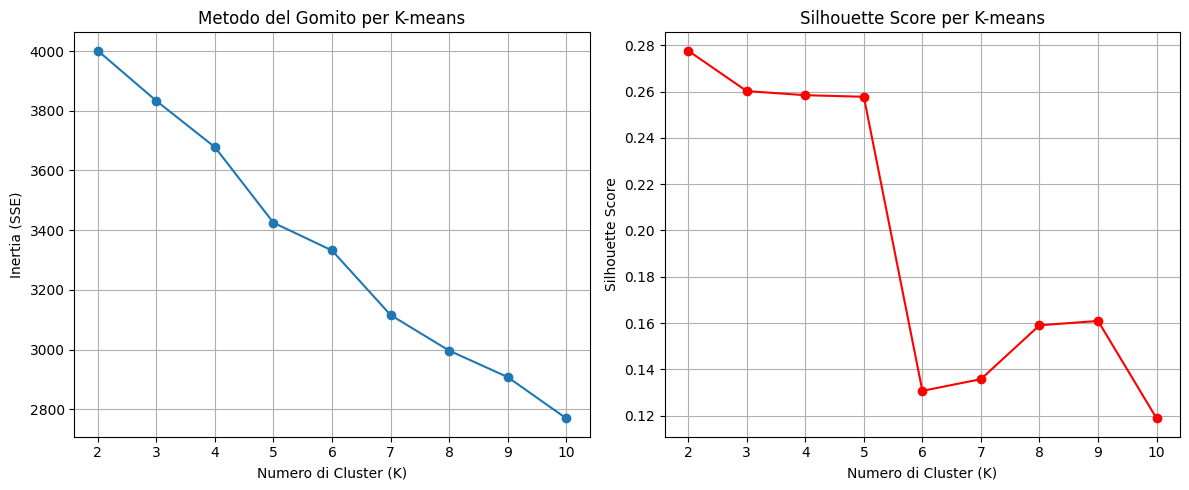


Analizza i grafici sopra per scegliere il numero ottimale di cluster (K).
Il 'gomito' nel grafico dell'Inertia e il picco nello Silhouette Score indicano un buon K.

--- K-means Clustering Finale ---
Distribuzione dei cluster K-means: Counter({0: 103, 1: 26, 2: 7, 3: 4})
Silhouette Score per K-means finale: 0.258

--- Analisi Semantica Latente (LSA) sui vettori Doc2vec ---

Prime 5 righe dei componenti LSA con i cluster K-means:
   LSA_Component_1  LSA_Component_2  LSA_Component_3  kmeans_cluster
0         1.659613         0.114662         0.335957               0
1         5.123578        11.613172        -4.228305               1
2         1.463905         0.452676         0.384167               0
3         0.756020         0.210808        -0.760188               0
4         1.716344         1.551489         1.656025               2

--- Visualizzazione dei Cluster nello Spazio LSA (Componenti 1 e 2) ---


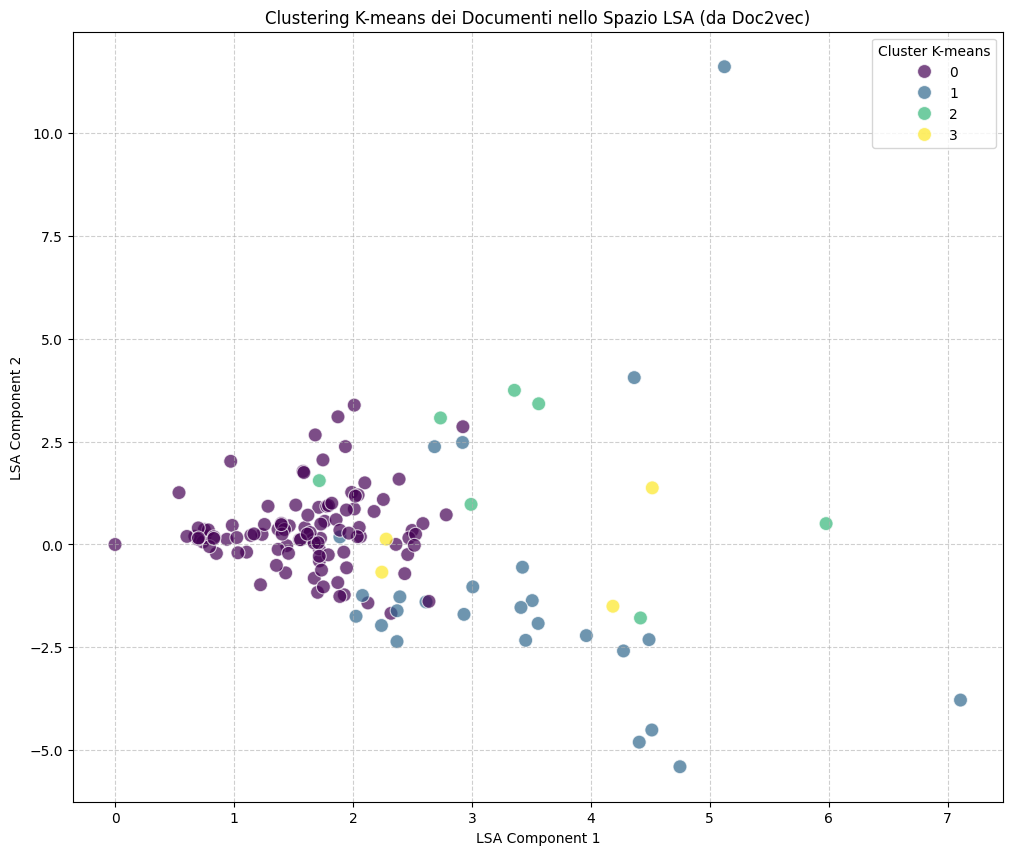


--- Clustering Gerarchico ---


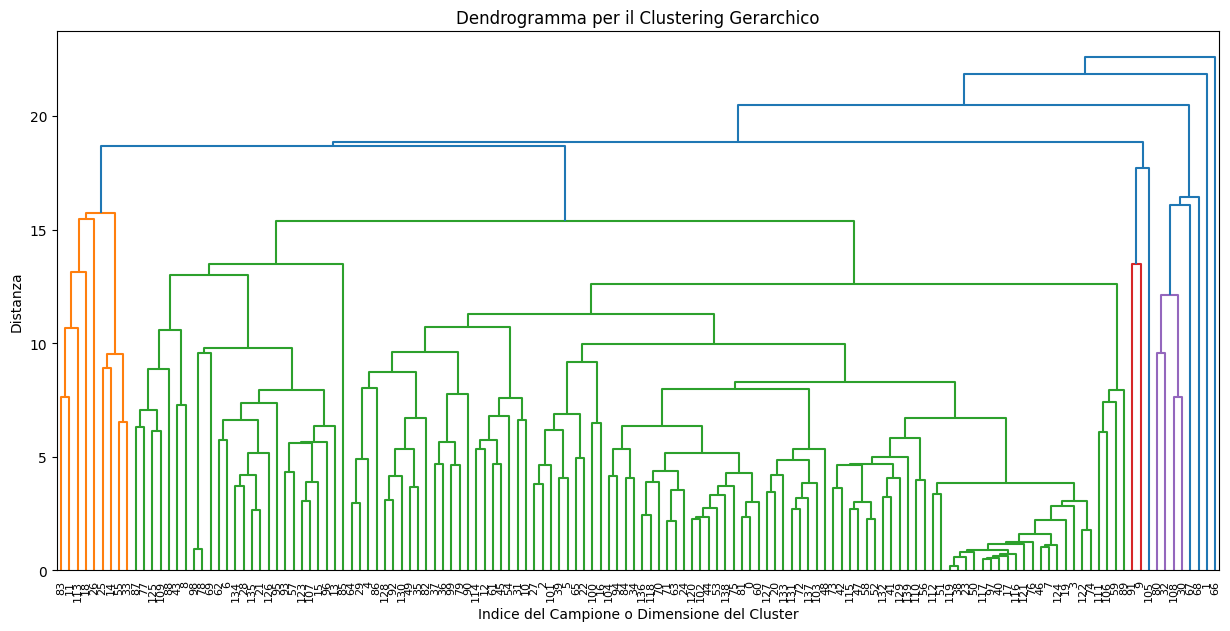


Analizza il dendrogramma per scegliere il numero di cluster.
Cerca le 'linee orizzontali' più lunghe che non sono intersecate da molte linee verticali.
Tagliando il dendrogramma a una certa altezza, puoi determinare il numero di cluster.

Distribuzione dei cluster Gerarchici: Counter({0: 117, 1: 21, 2: 1, 3: 1})
Silhouette Score per Clustering Gerarchico: 0.057

--- Visualizzazione dei Cluster Gerarchici nello Spazio LSA (Componenti 1 e 2) ---


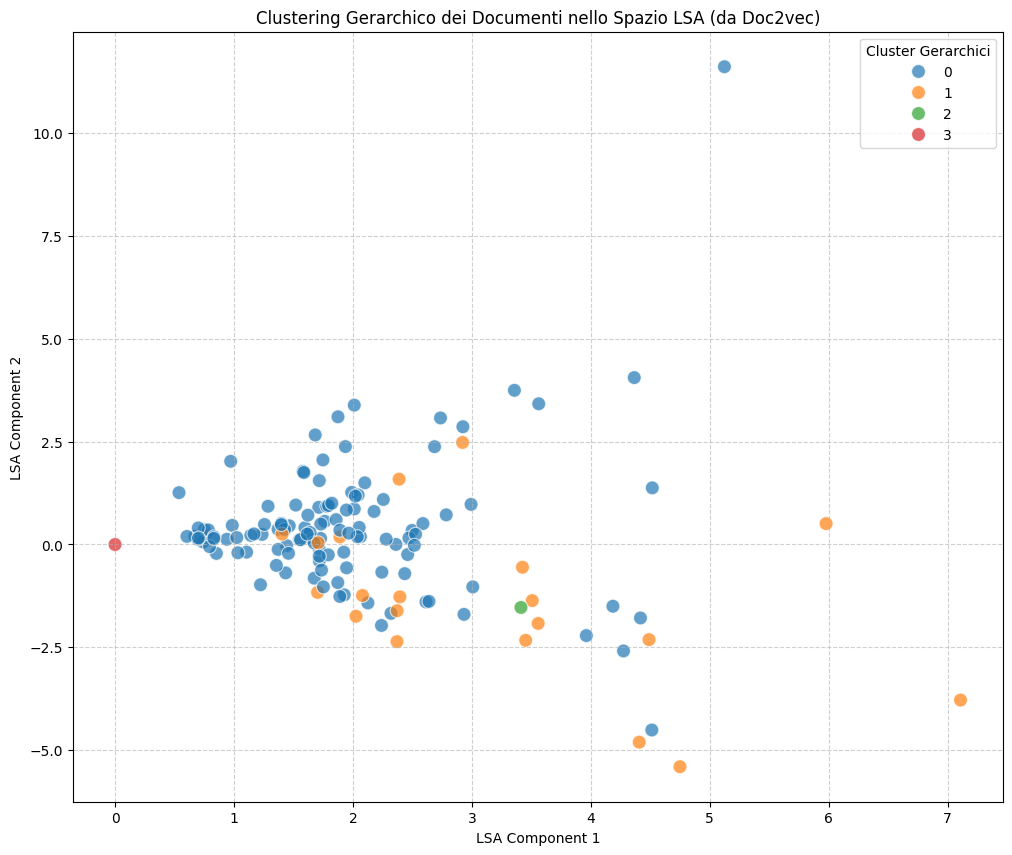


--- Fine delle operazioni di Clustering e LSA ---


In [21]:
#applicato su X_initial che contiene la rappresentazione Doc2vec originale non bilanciata
# --- Clustering con K-means e LSA su X_initial (Doc2vec originale) ---

print("\n--- Clustering K-means e LSA su Doc2vec Originale (X_initial) ---")

# --- Ottimizzazione del Numero di Cluster per K-means (Metodo del Gomito e Silhouette Score) ---
print("\n--- Ottimizzazione del Numero di Cluster (K-means) ---")

sse = [] # Sum of squared distances
silhouette_scores = []
k_range = range(2, 11) # Test da 2 a 10 cluster

for k in k_range:
    kmeans_opt = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans_opt.fit(X_initial)
    sse.append(kmeans_opt.inertia_)
    
    # Calcola Silhouette Score solo se ci sono almeno 2 cluster e più di 1 campione
    if len(np.unique(kmeans_opt.labels_)) > 1 and len(X_initial) > 1:
        silhouette_scores.append(silhouette_score(X_initial, kmeans_opt.labels_))
    else:
        silhouette_scores.append(0) # O np.nan, a seconda di come vuoi visualizzarlo

# Plot del Metodo del Gomito
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, sse, marker='o')
plt.xlabel('Numero di Cluster (K)')
plt.ylabel('Inertia (SSE)')
plt.title('Metodo del Gomito per K-means')
plt.grid(True)

# Plot dello Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o', color='red')
plt.xlabel('Numero di Cluster (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score per K-means')
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nAnalizza i grafici sopra per scegliere il numero ottimale di cluster (K).")
print("Il 'gomito' nel grafico dell'Inertia e il picco nello Silhouette Score indicano un buon K.")


# --- K-means Clustering Finale (con n_clusters scelto dopo l'analisi) ---
print("\n--- K-means Clustering Finale ---")
# Modifica n_clusters_kmeans qui dopo aver analizzato i grafici
n_clusters_kmeans = 4 # Esempio: mantengo 5, ma tu lo cambierai in base all'analisi
kmeans = KMeans(n_clusters=n_clusters_kmeans, random_state=42, n_init='auto')
clusters_kmeans = kmeans.fit_predict(X_initial)

# Crea una serie pandas con i cluster K-means
clusters_series_kmeans = pd.Series(clusters_kmeans, index=reviews_a.index)

# Aggiungi i cluster al DataFrame originale per analisi future
reviews_a['kmeans_cluster'] = clusters_series_kmeans

print(f"Distribuzione dei cluster K-means: {Counter(clusters_kmeans)}")

# Calcolo dello Silhouette Score per K-means finale
if len(np.unique(clusters_kmeans)) > 1: # Silhouette Score richiede almeno 2 cluster
    silhouette_avg_kmeans = silhouette_score(X_initial, clusters_kmeans)
    print(f"Silhouette Score per K-means finale: {silhouette_avg_kmeans:.3f}")
else:
    print("Non è possibile calcolare lo Silhouette Score: è stato trovato un solo cluster.")


# --- Analisi Semantica Latente (LSA) su Doc2vec ---
print("\n--- Analisi Semantica Latente (LSA) sui vettori Doc2vec ---")
n_components_lsa = 3 # Numero di componenti LSA desiderati
lsa_model = TruncatedSVD(n_components=n_components_lsa, random_state=42)

# Applica LSA ai vettori Doc2vec originali
doc2vec_lsa_components = lsa_model.fit_transform(X_initial)

# Crea un DataFrame con i componenti LSA
lsa_components_df = pd.DataFrame(doc2vec_lsa_components, 
                                 columns=[f'LSA_Component_{i+1}' for i in range(n_components_lsa)],
                                 index=reviews_a.index)

# Unisci i componenti LSA con i cluster K-means
lsa_components_df['kmeans_cluster'] = clusters_series_kmeans

print("\nPrime 5 righe dei componenti LSA con i cluster K-means:")
print(lsa_components_df.head())

# --- Visualizzazione dei Cluster nello Spazio LSA ---
print("\n--- Visualizzazione dei Cluster nello Spazio LSA (Componenti 1 e 2) ---")
plt.figure(figsize=(12, 10))
sns.scatterplot(x='LSA_Component_1', y='LSA_Component_2', hue='kmeans_cluster', 
                palette='viridis', data=lsa_components_df, s=100, alpha=0.7)
plt.xlabel('LSA Component 1')
plt.ylabel('LSA Component 2')
plt.title('Clustering K-means dei Documenti nello Spazio LSA (da Doc2vec)')
plt.legend(title='Cluster K-means')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- Clustering Gerarchico ---
print("\n--- Clustering Gerarchico ---")

# Genera la matrice di linkage (metodo 'ward' minimizza la varianza intra-cluster)
# Puoi provare anche 'average', 'complete', 'single'
linked = linkage(X_initial, method='ward')

# Visualizza il dendrogramma
plt.figure(figsize=(15, 7))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           leaf_rotation=90,
           leaf_font_size=8)
plt.title('Dendrogramma per il Clustering Gerarchico')
plt.xlabel('Indice del Campione o Dimensione del Cluster')
plt.ylabel('Distanza')
plt.show()

print("\nAnalizza il dendrogramma per scegliere il numero di cluster.")
print("Cerca le 'linee orizzontali' più lunghe che non sono intersecate da molte linee verticali.")
print("Tagliando il dendrogramma a una certa altezza, puoi determinare il numero di cluster.")

# Esegui il Clustering Gerarchico con un numero di cluster scelto
# Sostituisci 'n_clusters_hierarchical' con il numero di cluster che hai identificato dal dendrogramma
n_clusters_hierarchical = 4 # Esempio: imposta questo valore dopo aver analizzato il dendrogramma

# Per AgglomerativeClustering con distanza coseno, 'linkage' deve essere 'average', 'complete' o 'single'
# 'centroid' con 'cosine' affinity non è supportato direttamente in sklearn.
hierarchical_cluster = AgglomerativeClustering(n_clusters=n_clusters_hierarchical, metric='cosine', linkage='average') # Modificato: affinity='cosine', linkage='average'
clusters_hierarchical = hierarchical_cluster.fit_predict(X_initial)

# Crea una serie pandas con i cluster Gerarchici
clusters_series_hierarchical = pd.Series(clusters_hierarchical, index=reviews_a.index)

# Aggiungi i cluster al DataFrame originale
reviews_a['hierarchical_cluster'] = clusters_series_hierarchical

print(f"\nDistribuzione dei cluster Gerarchici: {Counter(clusters_hierarchical)}")

# Calcolo dello Silhouette Score per il Clustering Gerarchico
if len(np.unique(clusters_hierarchical)) > 1:
    silhouette_avg_hierarchical = silhouette_score(X_initial, clusters_hierarchical, metric='cosine') 
    print(f"Silhouette Score per Clustering Gerarchico: {silhouette_avg_hierarchical:.3f}")
else:
    print("Non è possibile calcolare lo Silhouette Score: è stato trovato un solo cluster nel clustering gerarchico.")

# --- Visualizzazione dei Cluster Gerarchici nello Spazio LSA ---
print("\n--- Visualizzazione dei Cluster Gerarchici nello Spazio LSA (Componenti 1 e 2) ---")
# Assicurati che lsa_components_df abbia già i componenti LSA calcolati
lsa_components_df['hierarchical_cluster'] = clusters_series_hierarchical

plt.figure(figsize=(12, 10))
sns.scatterplot(x='LSA_Component_1', y='LSA_Component_2', hue='hierarchical_cluster', 
                palette='tab10', # Usa una palette diversa per distinguere da K-means
                data=lsa_components_df, s=100, alpha=0.7)
plt.xlabel('LSA Component 1')
plt.ylabel('LSA Component 2')
plt.title('Clustering Gerarchico dei Documenti nello Spazio LSA (da Doc2vec)')
plt.legend(title='Cluster Gerarchici')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


print("\n--- Fine delle operazioni di Clustering e LSA ---")


In [22]:
# --- Preparazione Dati
print("\n--- Preparazione Dati e Applicazione Regressione Logistica (per la classificazione del Rating) ---")

# Definisci le feature (X) e la variabile target (y)
# Utilizziamo X_res_rating e y_res_rating, il dataset bilanciato per il rating dalla Fase 1.
X_model = X_res_rating
y_model = y_res_rating

print(f"\nDimensione del dataset X per il modello: {X_model.shape}")
print(f"Dimensione del dataset y per il modello: {y_model.shape}")
print(f"Distribuzione del Rating nel dataset bilanciato per il modello: {Counter(y_model)}")

# Suddivisione del dataset in training e validation set
# random_state per riproducibilità
# stratify=y_model per mantenere la stessa proporzione di classi in training e validation
X_train, X_val, y_train, y_val = train_test_split(X_model, y_model, test_size=0.2, random_state=42, stratify=y_model)

print(f"\nDimensione del Training Set (X_train): {X_train.shape}")
print(f"Dimensione del Validation Set (X_val): {X_val.shape}")
print(f"Distribuzione del Rating nel Training Set: {Counter(y_train)}")
print(f"Distribuzione del Rating nel Validation Set: {Counter(y_val)}")



--- Preparazione Dati e Applicazione Regressione Logistica (per la classificazione del Rating) ---

Dimensione del dataset X per il modello: (470, 100)
Dimensione del dataset y per il modello: (470,)
Distribuzione del Rating nel dataset bilanciato per il modello: Counter({5: 94, 4: 94, 1: 94, 3: 94, 2: 94})

Dimensione del Training Set (X_train): (376, 100)
Dimensione del Validation Set (X_val): (94, 100)
Distribuzione del Rating nel Training Set: Counter({2: 76, 1: 75, 5: 75, 4: 75, 3: 75})
Distribuzione del Rating nel Validation Set: Counter({4: 19, 5: 19, 3: 19, 1: 19, 2: 18})


In [23]:
#Logistic Regression
def model_logistic_regression(X_train, X_test, y_train, y_test):
    # 1. Creazione e addestramento del modello
    model_lg = LogisticRegression(max_iter=500, random_state=42)
    model_lg.fit(X_train, y_train)

    # 2. Previsioni sul test set
    y_pred_test = model_lg.predict(X_test)
    y_pred_train = model_lg.predict(X_train)
    
# 3. Calcola le metriche di valutazione per la classificazione
    accuracy_train = accuracy_score(y_train, y_pred_train)
    precision_train = precision_score(y_train, y_pred_train, average='weighted')
    recall_train = recall_score(y_train, y_pred_train, average='weighted')
    f1_train = f1_score(y_train, y_pred_train, average='weighted')

    accuracy_test = accuracy_score(y_test, y_pred_test)
    precision_test = precision_score(y_test, y_pred_test, average='weighted')
    recall_test = recall_score(y_test, y_pred_test, average='weighted')
    f1_test = f1_score(y_test, y_pred_test, average='weighted')

    # 4. Stampa le metriche di valutazione
    print("Valutazione train")
    print(f"Accuracy: {accuracy_train}, Precision: {precision_train}, Recall: {recall_train}, F1-score: {f1_train}")
    print("Valutazione test")
    print(f"Accuracy: {accuracy_test}, Precision: {precision_test}, Recall: {recall_test}, F1-score: {f1_test}")

    return model_lg

In [26]:
modello_log_reg= model_logistic_regression(X_train,X_val, y_train, y_val)

Valutazione train
Accuracy: 0.9308510638297872, Precision: 0.9308558356576426, Recall: 0.9308510638297872, F1-score: 0.9307467809806093
Valutazione test
Accuracy: 0.8297872340425532, Precision: 0.8239985192112852, Recall: 0.8297872340425532, F1-score: 0.8210931891922933


In [27]:
#Gradient Boosting
def model_gradient_boosting(X_train, X_test, y_train, y_test):
     # 1. Creazione e addestramento del modello
    model_gb = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.5, subsample=0.75)
    model_gb.fit(X_train, y_train)

    # 2. Previsioni sul test set
    y_pred_test = model_gb.predict(X_test)
    y_pred_train = model_gb.predict(X_train)

    # 3. Calcola le metriche di valutazione per la classificazione
    accuracy_train = accuracy_score(y_train, y_pred_train)
    precision_train = precision_score(y_train, y_pred_train, average='weighted')
    recall_train = recall_score(y_train, y_pred_train, average='weighted')
    f1_train = f1_score(y_train, y_pred_train, average='weighted')

    accuracy_test = accuracy_score(y_test, y_pred_test)
    precision_test = precision_score(y_test, y_pred_test, average='weighted')
    recall_test = recall_score(y_test, y_pred_test, average='weighted')
    f1_test = f1_score(y_test, y_pred_test, average='weighted')

    # 4. Stampa le metriche di valutazione
    print("Valutazione train")
    print(f"Accuracy: {accuracy_train}, Precision: {precision_train}, Recall: {recall_train}, F1-score: {f1_train}")
    print("Valutazione test")
    print(f"Accuracy: {accuracy_test}, Precision: {precision_test}, Recall: {recall_test}, F1-score: {f1_test}")

    return model_gb

In [31]:
modello_gb= model_gradient_boosting(X_train,X_val, y_train, y_val)

Valutazione train
Accuracy: 1.0, Precision: 1.0, Recall: 1.0, F1-score: 1.0
Valutazione test
Accuracy: 0.8617021276595744, Precision: 0.8655604859609866, Recall: 0.8617021276595744, F1-score: 0.8617261892560283


In [32]:
#rete neurale
def modello_lstm_text_pre_split(X_train_nn, y_train_nn, X_val_nn, y_val_nn, epochs=10, learning_rate=0.001, dropout_rate=0.2, l2_rate=0.001):
    num_classes = len(np.unique(y_train_nn)) # Ottieni il numero di classi uniche dalle etichette

    # Input per le feature combinate (Doc2Vec)
    input_layer = Input(shape=(X_train_nn.shape[1],)) # La dimensione dell'input è il numero di feature

    # Rimodella l'input per avere una dimensione di sequenza (timesteps=1)
    # LSTM si aspetta input di forma (batch_size, timesteps, features)
    reshape_layer = Reshape((1, X_train_nn.shape[1]))(input_layer)

    # Layer LSTM con regolarizzazione L2 e Dropout
    lstm_layer = LSTM(128, kernel_regularizer=l2(l2_rate))(reshape_layer) # L'LSTM ora riceve una sequenza di lunghezza 1
    dropout_layer = Dropout(dropout_rate)(lstm_layer)

    # Output layer per la classificazione multi-classe
    output_layer = Dense(num_classes)(dropout_layer)
    output_layer = Activation('softmax')(output_layer)

    model = Model(inputs=input_layer, outputs=output_layer)
    
    # Compila il modello per la classificazione multi-classe
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer,
                  loss=SparseCategoricalCrossentropy(from_logits=False),  # Usa False se hai la softmax
                  metrics=[SparseCategoricalAccuracy()])

    print("\nArchitettura del Modello LSTM:")
    model.summary()

    history = model.fit(X_train_nn, y_train_nn, 
                        epochs=epochs, 
                        validation_data=(X_val_nn, y_val_nn),
                        verbose=1) # verbose=1 per mostrare l'avanzamento

    return model, history


--- Applicazione della Rete Neurale LSTM (per la classificazione del Rating) ---

Architettura del Modello LSTM:


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_5 (Reshape)                  │ (None, 1, 100)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ (None, 128)                 │         117,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 5)                   │             645 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 5)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 117,893 (460.52 KB)

 Trainable params: 117,893 (460.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - loss: 1.7479 - sparse_categorical_accuracy: 0.3034 - val_loss: 1.5659 - val_sparse_categorical_accuracy: 0.5000
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1.5017 - sparse_categorical_accuracy: 0.5941 - val_loss: 1.3874 - val_sparse_categorical_accuracy: 0.5851
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.3424 - sparse_categorical_accuracy: 0.6887 - val_loss: 1.2522 - val_sparse_categorical_accuracy: 0.5532
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.1735 - sparse_categorical_accuracy: 0.7283 - val_loss: 1.1503 - val_sparse_categorical_accuracy: 0.6170
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.0315 - sparse_categorical_accuracy: 0.7645 - val_loss: 1.0684 - val_sparse_categorical_accuracy: 0.6383
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.9695 - sparse_categorical_accuracy: 0.7588 - val_loss: 1.0132 - val_sparse_categorical_accuracy: 0.6702
Epoc

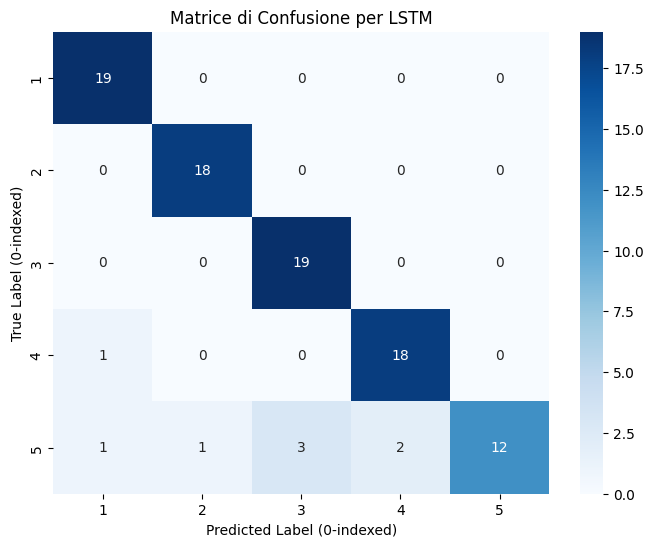

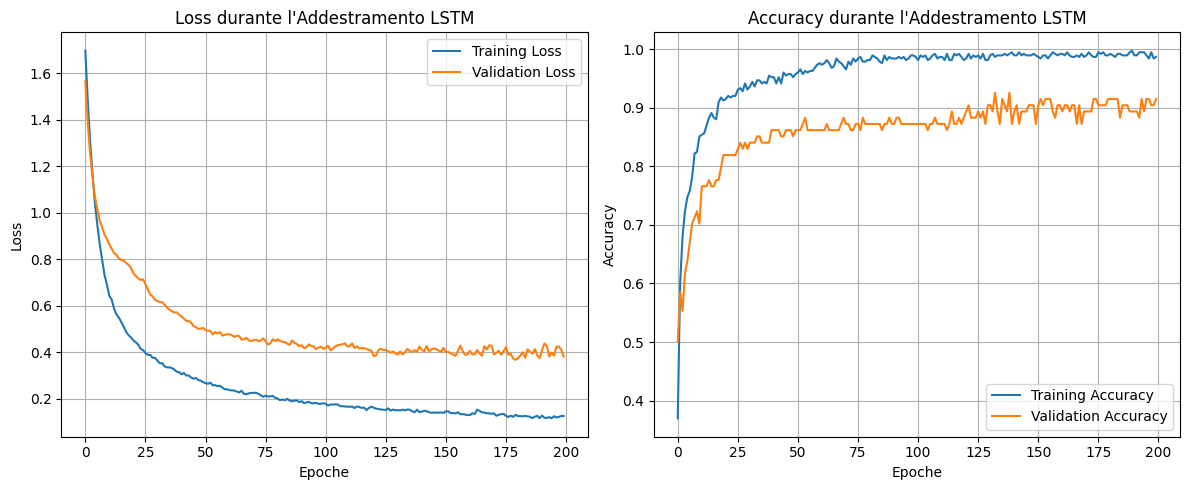


--- Fine della Rete Neurale LSTM ---


In [41]:
# --- Applicazione della Rete Neurale LSTM ---
print("\n--- Applicazione della Rete Neurale LSTM (per la classificazione del Rating) ---")

# Prepara i dati per la rete neurale
# Le etichette devono essere 0-indicizzate per SparseCategoricalCrossentropy
y_train_nn = y_train - 1
y_val_nn = y_val - 1

# Converti i DataFrame/Series in array NumPy per TensorFlow
X_train_nn = X_train.values
X_val_nn = X_val.values

# Parametri per la rete neurale
epochs_nn = 200 # Puoi aumentare o diminuire questo valore
learning_rate_nn = 0.001
dropout_rate_nn = 0.3 # Tasso di dropout
l2_rate_nn = 0.001 # Tasso di regolarizzazione L2

# Chiama la funzione per costruire e addestrare il modello LSTM
lstm_model, lstm_history = modello_lstm_text_pre_split(
    X_train_nn, y_train_nn, X_val_nn, y_val_nn,
    epochs=epochs_nn, learning_rate=learning_rate_nn,
    dropout_rate=dropout_rate_nn, l2_rate=l2_rate_nn
)

# Valutazione finale del modello LSTM sul set di validation
print("\n--- Valutazione Finale del Modello LSTM ---")
loss, accuracy = lstm_model.evaluate(X_val_nn, y_val_nn, verbose=0)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

# Predizioni e Classification Report per LSTM
y_pred_nn_probs = lstm_model.predict(X_val_nn)
y_pred_nn = np.argmax(y_pred_nn_probs, axis=1)

print("\nClassification Report (LSTM):")
#y_val_nn è 0-indicizzato, quindi il report sarà per 0-4
print(classification_report(y_val_nn, y_pred_nn, target_names=[str(i) for i in sorted(np.unique(y_model))])) # Per mostrare le etichette originali 1-5

# Matrice di Confusione per LSTM
conf_matrix_nn = confusion_matrix(y_val_nn, y_pred_nn)
print("\nMatrice di Confusione (LSTM):")
print(conf_matrix_nn)

# Visualizzazione della Matrice di Confusione per LSTM
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_nn, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(np.unique(y_model)), yticklabels=sorted(np.unique(y_model))) # Etichette originali 1-5
plt.xlabel('Predicted Label (0-indexed)')
plt.ylabel('True Label (0-indexed)')
plt.title('Matrice di Confusione per LSTM')
plt.show()

# Plot delle curve di Loss e Accuracy durante l'addestramento
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(lstm_history.history['loss'], label='Training Loss')
plt.plot(lstm_history.history['val_loss'], label='Validation Loss')
plt.title('Loss durante l\'Addestramento LSTM')
plt.xlabel('Epoche')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(lstm_history.history['sparse_categorical_accuracy'], label='Training Accuracy')
plt.plot(lstm_history.history['val_sparse_categorical_accuracy'], label='Validation Accuracy')
plt.title('Accuracy durante l\'Addestramento LSTM')
plt.xlabel('Epoche')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n--- Fine della Rete Neurale LSTM ---")